Here we have the imports needed

In [57]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import random
import yaml
from scipy.integrate import quad
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

We extract our dataset

\Points: 22   z ∈ [0.140, 0.980]
WOrkspace range: [0.0700, 1.0000]

      z    (1/N)dN/dz           σ    σ/y [%]
----------------------------------------------
 0.1400      0.116000    0.030676       26.4%
 0.1800      0.198000    0.037135       18.8%
 0.2200      0.247000    0.030561       12.4%
 0.2600      0.264000    0.028983       11.0%
 0.3000      0.308000    0.032171       10.4%
 0.3400      0.370000    0.032909        8.9%
 0.3800      0.426000    0.034713        8.1%
 0.4200      0.501000    0.038419        7.7%
 0.4600      0.577000    0.040927        7.1%
 0.5000      0.685000    0.041785        6.1%
 0.5400      0.833000    0.052811        6.3%
 0.5800      1.055000    0.074061        7.0%
 0.6200      1.311000    0.089039        6.8%
 0.6600      1.667000    0.087892        5.3%
 0.7000      2.080000    0.084119        4.0%
 0.7400      2.566000    0.116263        4.5%
 0.7800      2.934000    0.178037        6.1%
 0.8200      3.104000    0.234949        7.6%
 0.8600     

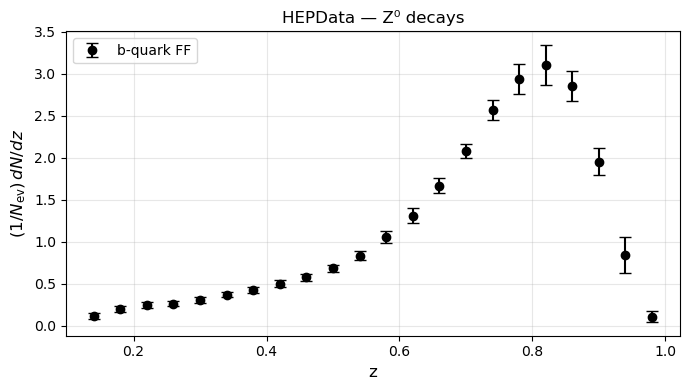

In [58]:
YAML_FILE="Table1.yaml"


def load_hepdata_yaml(filepath):
    """Load the HEPData dataset.
    REturns z_data, y_data, sigma_data.
    """
    with open(filepath, 'r') as f:
        raw = yaml.safe_load(f)

    #momentum fraction z
    indep = raw['independent_variables'][0]
    
    z_data = []
    for pt in indep['values']:
        if 'value' in pt:
            z_data.append(float(pt['value']))
        elif 'low' in pt and 'high' in pt:
            z_data.append(0.5 * (float(pt['low']) + float(pt['high'])))
        else:
            raise ValueError(f"unexpected format: {pt}")
    z_data = np.array(z_data)

    # (1/N) dN/dx
    dep = raw['dependent_variables'][0]

    y_data, sigma_data = [], []
    for pt in dep['values']:
        y_data.append(float(pt['value']))
        err_sq = 0.0
        for err in pt.get('errors', []):
            if 'symerror' in err:
                err_sq += float(err['symerror'])**2
            elif 'asymerror' in err:
                up = abs(float(err['asymerror'].get('plus',  0)))
                dn = abs(float(err['asymerror'].get('minus', 0)))
                err_sq += ((up + dn) / 2.0)**2
        sigma_data.append(max(np.sqrt(err_sq), 1e-6))

    return z_data, np.array(y_data), np.array(sigma_data)

z_data, y_data, sigma_data = load_hepdata_yaml(YAML_FILE)


Z_MIN = max(z_data.min() * 0.5, 1e-4)  
Z_MAX = min(z_data.max() * 1.05, 1)

print(f"\Points: {len(z_data)}   z ∈ [{z_data.min():.3f}, {z_data.max():.3f}]")
print(f"WOrkspace range: [{Z_MIN:.4f}, {Z_MAX:.4f}]")
print(f"\n{'z':>7}  {'(1/N)dN/dz':>12}  {'σ':>10}  {'σ/y [%]':>9}")
print("-" * 46)
for z, y, s in zip(z_data, y_data, sigma_data):
    print(f"{z:7.4f}  {y:12.6f}  {s:10.6f}  {100*s/max(abs(y),1e-9):9.1f}%")

plt.figure(figsize=(7, 4))
plt.errorbar(z_data, y_data, yerr=sigma_data,
             fmt='ko', capsize=4, label='b-quark FF')
plt.xlabel('z', fontsize=12)
plt.ylabel(r'$(1/N_{\rm ev})\,dN/dz$', fontsize=12)
plt.title('HEPData — Z⁰ decays')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()



We define our variables that define our phase space and the number of qubits needed

In [59]:

PARAM_NAMES      = ['N', 'epsilon']

# ranges
#   N       ∈ [0.0001, 5.0]    normalization
#   epsilon ∈ [0.00001, 0.30]  Peterson's parameter for heavy quarks
#            (tipically: ε_b ≈ 0.006 – 0.030)
PARAM_MIN        = np.array([0.0001,  0.002])
PARAM_MAX        = np.array([1.0,   0.1 ])
N_PARAMS         = 2
QUBITS_PER_PARAM = 7
NUM_QUBITS       = N_PARAMS * QUBITS_PER_PARAM   

print(f"REsolution: 2^{QUBITS_PER_PARAM} = {2**QUBITS_PER_PARAM} values per parameter")
for name, lo, hi in zip(PARAM_NAMES, PARAM_MIN, PARAM_MAX):
    step = (hi - lo) / (2**QUBITS_PER_PARAM-1)
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]   step = {step:.6f}")



def peterson_raw(z, N, epsilon):
    """D(z; N, ε) = N / [z * (1+alpha - 1/z - ε/(1-z))²]
    """
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    denom_inner = 1.0- 1.0/z - epsilon/(1.0 - z)
    denom = z * denom_inner**2
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, N / denom, 0.0)
    return np.maximum(val, 0.0)   # FF is positive


_norm_cache = {}  

def compute_norm(N, epsilon, z_lo=Z_MIN, z_hi=Z_MAX):
    """Integral numérica de D(z; N, ε) en [z_lo, z_hi]."""
    key = (round(N, 6), round(epsilon, 8))
    if key in _norm_cache:
        return _norm_cache[key]
    val, _ = quad(lambda z: peterson_raw(z, N, epsilon),
                  z_lo, z_hi, limit=100,
                  points=[1.0/(1.0 + epsilon**0.5)])  # pico analítico
    _norm_cache[key] = val
    return val


def ff_model(z, theta):
    N, epsilon = theta
    if N <= 0 or epsilon <= 0:
        return np.zeros_like(np.asarray(z, dtype=float))
    return peterson_raw(z, N, epsilon)


def chi2_ff(theta):
    """χ²(θ) = Σ [(D̃_modell - y)² / σ²]"""
    f = ff_model(z_data, theta)
    if not np.all(np.isfinite(f)):
        return 1e12
    chi2 = float(np.sum(((f - y_data) / sigma_data)**2))
    return chi2 if np.isfinite(chi2) else 1e12



REsolution: 2^7 = 128 values per parameter
  N       : [0.0001, 1.0000]   step = 0.007873
  epsilon : [0.0020, 0.1000]   step = 0.000772


Instead of anoisy backed we use a normal one

In [60]:
def get_backend():
    return AerSimulator()

Quantum operators

In [61]:

def initialize_chromosome(num_qubits):

    qc = QuantumCircuit(num_qubits)


    qc.h(range(num_qubits))


    for i in range(num_qubits - 1 ):
        qc.cx(i, i + 1)

    qc.barrier()
    return qc


def measure_chromosome(qc, backend):

    qc_m = qc.copy()
    qc_m.measure_all()
    qc_m   = transpile(qc_m, backend)
    counts = backend.run(qc_m, shots=1).result().get_counts()
    return list(counts.keys())[0][::-1]   

def decode_parameters(binary_string):

    max_int = (2 ** QUBITS_PER_PARAM) - 1   
    params  = []
    for k in range(N_PARAMS):
        chunk   = binary_string[k * QUBITS_PER_PARAM : (k + 1) * QUBITS_PER_PARAM]
        int_val = int(chunk, 2)             
        val     = PARAM_MIN[k] + (PARAM_MAX[k] - PARAM_MIN[k]) * (int_val / max_int)
        params.append(val)
    return np.array(params)


def apply_rotation(qc, best_binary, rotation_angle):
    """
      best_bit = 1 → RY(+θ)  (grows P(|1⟩))
      best_bit = 0 → RY(−θ)  (grows P(|0⟩))
    """
    for i in range(qc.num_qubits):
        if i >= len(best_binary):
            continue
        direction = +1 if int(best_binary[i]) == 1 else -1
        qc.ry(direction * rotation_angle, i)

    # Re-entrelazar tras la rotación
    for i in range(qc.num_qubits - 1):
        qc.cx(i, i + 1)
    return qc


def apply_mutation(qc, mutation_rate):
    
    qc.barrier()
    for i in range(qc.num_qubits):
        if random.random() < mutation_rate:
            qc.x(i)
    return qc

In [62]:
def run_qga(generations=80, population_size=20,
            rotation_angle=0.10, mutation_rate=0.04):
   
    backend    = get_backend()
    population = [initialize_chromosome(NUM_QUBITS)
                  for _ in range(population_size)]

    best_chi2   = float('inf')
    best_binary = None
    best_theta  = np.array([1.0, 0.006])  
    history     = []

    print(f"QGA — Peterson | {NUM_QUBITS} qubits | "
          f"pop={population_size} | gens={generations}")
    
    print("=" * 60)

    for gen in range(generations):
        gen_best_chi2   = float('inf')
        gen_best_binary = None

        for qc in population:
            binary = measure_chromosome(qc, backend)
            theta  = decode_parameters(binary)
            chi2   = chi2_ff(theta)

            if chi2 < gen_best_chi2:
                gen_best_chi2   = chi2
                gen_best_binary = binary

            if chi2 < best_chi2:
                best_chi2   = chi2
                best_binary = binary
                best_theta  = theta.copy()

        history.append(best_chi2)

        if gen_best_binary:
            for i in range(len(population)):
                population[i] = apply_rotation(
                    population[i], gen_best_binary, rotation_angle)
                population[i] = apply_mutation(
                    population[i], mutation_rate)

        print(f"Gen {gen+1:03d}: χ² = {best_chi2:9.4f}  "
                  f"N = {best_theta[0]:.4f}   ε = {best_theta[1]:.5f}")

    print("=" * 60)
    print(f"χ²_QGA  = {best_chi2:.6f}   χ²/n = {best_chi2/len(z_data):.4f}")
    print(f"N       = {best_theta[0]:.6f}")
    print(f"ε       = {best_theta[1]:.6f}")
    z_peak = 1.0 / (1.0 + best_theta[1]**0.5)
    print(f"z* (pico) = {z_peak:.4f}")

    return best_chi2, best_theta, population, history, best_binary


best_chi2, best_theta, pop, history, best_binary = run_qga(
    generations     = 100,
    population_size = 20,
    rotation_angle  = 0.1,
    mutation_rate   = 0.15)

QGA — Peterson | 14 qubits | pop=20 | gens=100
Gen 001: χ² =  202.5390  N = 0.5748   ε = 0.06142
Gen 002: χ² =  136.3765  N = 0.4804   ε = 0.03364
Gen 003: χ² =  136.3765  N = 0.4804   ε = 0.03364
Gen 004: χ² =   51.3107  N = 0.4567   ε = 0.04213
Gen 005: χ² =   51.3107  N = 0.4567   ε = 0.04213
Gen 006: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 007: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 008: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 009: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 010: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 011: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 012: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 013: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 014: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 015: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 016: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 017: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 018: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen 019: χ² =   46.6896  N = 0.4174   ε = 0.03364
Gen


Classical genetic algorithm using the same bits as qubits in the quantum.


In [63]:

def cga_random_individual():
    return ''.join(random.choice('01') for _ in range(NUM_QUBITS))


def cga_tournament_select(population, fitnesses, k=3):
    contestants = random.sample(range(len(population)), k)
    winner = min(contestants, key=lambda i: fitnesses[i])
    return population[winner]


def cga_two_point_crossover(parent_a, parent_b):
    if random.random() > 0.5:
        return parent_a, parent_b
    n = len(parent_a)
    p1, p2 = sorted(random.sample(range(1, n), 2))
    child_a = parent_a[:p1] + parent_b[p1:p2] + parent_a[p2:]
    child_b = parent_b[:p1] + parent_a[p1:p2] + parent_b[p2:]
    return child_a, child_b


def cga_mutate(individual, mutation_rate):
    flipped = []
    for bit in individual:
        if random.random() < mutation_rate:
            flipped.append('1' if bit == '0' else '0')
        else:
            flipped.append(bit)
    return ''.join(flipped)


def run_cga(generations=200, population_size=20, mutation_rate=0.03,
            tournament_k=3, seed=None):
   
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    #Initialization
    population = [cga_random_individual() for _ in range(population_size)]

    best_chi2  = float('inf')
    best_theta = np.array([1.0, 0.006])
    history    = []

    print(f"CGA — Peterson | {NUM_QUBITS} bits | "
          f"pop={population_size} | gens={generations} | "
          f"mut={mutation_rate}")

    for gen in range(generations):

        
        fitnesses = []
        for ind in population:
            theta = decode_parameters(ind)   
            fitnesses.append(chi2_ff(theta))

        
        gen_best_idx = int(np.argmin(fitnesses))
        if fitnesses[gen_best_idx] < best_chi2:
            best_chi2  = fitnesses[gen_best_idx]
            best_theta = decode_parameters(population[gen_best_idx]).copy()
        history.append(best_chi2)

        
        elite      = population[gen_best_idx]   
        next_gen   = [elite]

        while len(next_gen) < population_size:
            parent_a = cga_tournament_select(population, fitnesses, tournament_k)
            parent_b = cga_tournament_select(population, fitnesses, tournament_k)
            child_a, child_b = cga_two_point_crossover(parent_a, parent_b)
            next_gen.append(cga_mutate(child_a, mutation_rate))
            if len(next_gen) < population_size:
                next_gen.append(cga_mutate(child_b, mutation_rate))

        population = next_gen

        print(f"Gen {gen+1:03d}: chi2 = {best_chi2:9.4f}  "
              f"N = {best_theta[0]:.4f}   eps = {best_theta[1]:.5f}")

    print("=" * 60)
    print(f"chi2_CGA  = {best_chi2:.6f}   chi2/n = {best_chi2/len(z_data):.4f}")
    print(f"N         = {best_theta[0]:.6f}")
    print(f"eps       = {best_theta[1]:.6f}")

    return best_chi2, best_theta, history


cga_chi2, cga_theta, cga_history = run_cga(
    generations     = 100,
    population_size = 20,
    mutation_rate   = 0.03,
    tournament_k    = 3,
    seed            = 42
)


CGA — Peterson | 14 bits | pop=20 | gens=100 | mut=0.03
Gen 001: chi2 =   94.9322  N = 0.4489   eps = 0.04676
Gen 002: chi2 =   46.0096  N = 0.4410   eps = 0.03518
Gen 003: chi2 =   46.0096  N = 0.4410   eps = 0.03518
Gen 004: chi2 =   46.0096  N = 0.4410   eps = 0.03518
Gen 005: chi2 =   46.0096  N = 0.4410   eps = 0.03518
Gen 006: chi2 =   46.0096  N = 0.4410   eps = 0.03518
Gen 007: chi2 =   46.0096  N = 0.4410   eps = 0.03518
Gen 008: chi2 =   46.0096  N = 0.4410   eps = 0.03518
Gen 009: chi2 =   40.8944  N = 0.4410   eps = 0.03827
Gen 010: chi2 =   40.8944  N = 0.4410   eps = 0.03827
Gen 011: chi2 =   40.8944  N = 0.4410   eps = 0.03827
Gen 012: chi2 =   40.8944  N = 0.4410   eps = 0.03827
Gen 013: chi2 =   40.6235  N = 0.4410   eps = 0.03672
Gen 014: chi2 =   40.6235  N = 0.4410   eps = 0.03672
Gen 015: chi2 =   40.6235  N = 0.4410   eps = 0.03672
Gen 016: chi2 =   40.6235  N = 0.4410   eps = 0.03672
Gen 017: chi2 =   40.6235  N = 0.4410   eps = 0.03672
Gen 018: chi2 =   40.6235 

Final cirquit
  gates    : 2962


  deep: 1439
  binary chain: 01110010110001
  N = 0.4489   ε = 0.03981


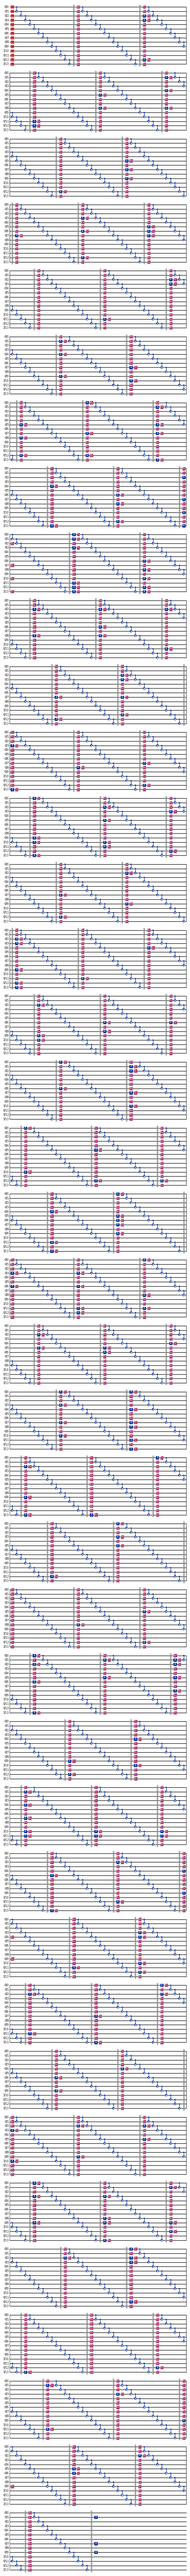

In [64]:

best_qc = pop[0]

print("Final cirquit")
print(f"  gates    : {best_qc.size()}")
print(f"  deep: {best_qc.depth()}")
print(f"  binary chain: {best_binary}")
print(f"  N = {best_theta[0]:.4f}   ε = {best_theta[1]:.5f}")

fig2 = best_qc.draw(output='mpl', style='iqp', fold=40, scale=0.50)
fig2.set_size_inches(100, 75)
plt.tight_layout()
plt.show()


QGA vs CGA 


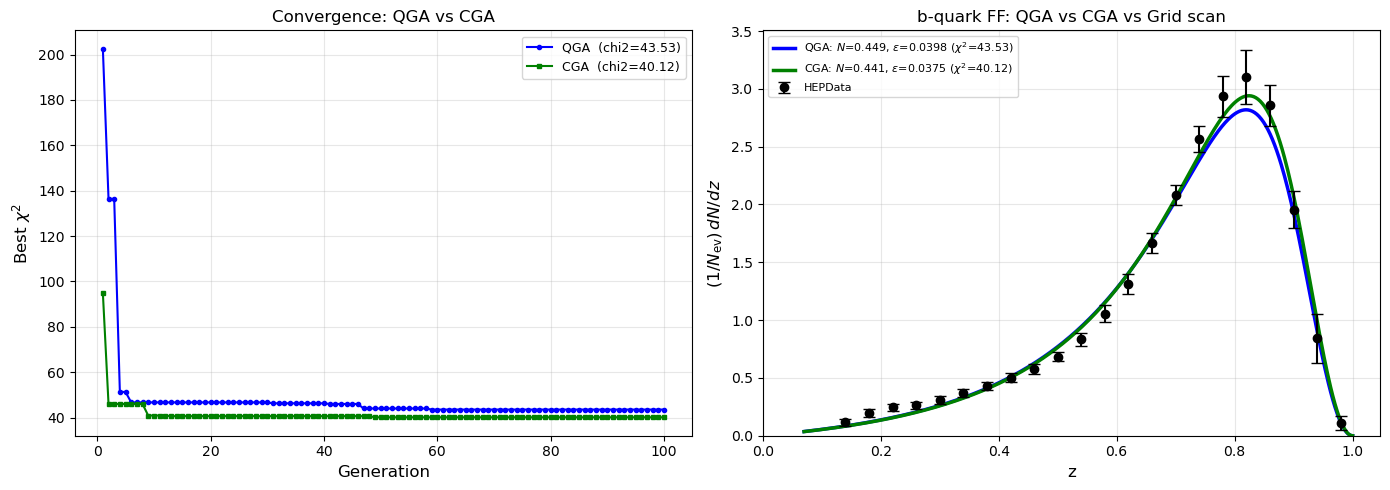


Method              N    epsilon       chi2   chi2/n
-------------------------------------------------------
CGA            0.4410    0.03750    40.1224   1.8237
QGA            0.4489    0.03981    43.5322   1.9787


In [65]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gen_axis_qga = np.arange(1, len(history)     + 1)
gen_axis_cga = np.arange(1, len(cga_history) + 1)

axes[0].plot(gen_axis_qga, history,     'b-o', markersize=3, lw=1.5,
             label=f'QGA  (chi2={best_chi2:.2f})')
axes[0].plot(gen_axis_cga, cga_history, 'g-s', markersize=3, lw=1.5,
             label=f'CGA  (chi2={cga_chi2:.2f})')

axes[0].set_xlabel('Generation', fontsize=12)
axes[0].set_ylabel(r'Best $\chi^2$', fontsize=12)
axes[0].set_title('Convergence: QGA vs CGA')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

z_fine    = np.linspace(Z_MIN, Z_MAX, 500)
f_qga_    = ff_model(z_fine, best_theta)
f_cga_    = ff_model(z_fine, cga_theta)

axes[1].errorbar(z_data, y_data, yerr=sigma_data,
                 fmt='ko', capsize=4, label='HEPData', zorder=5)
axes[1].plot(z_fine, f_qga_, 'b-',  lw=2.5,
             label=(rf'QGA: $N$={best_theta[0]:.3f}, '
                    rf'$\varepsilon$={best_theta[1]:.4f} '
                    rf'($\chi^2$={best_chi2:.2f})'))
axes[1].plot(z_fine, f_cga_, 'g-',  lw=2.5,
             label=(rf'CGA: $N$={cga_theta[0]:.3f}, '
                    rf'$\varepsilon$={cga_theta[1]:.4f} '
                    rf'($\chi^2$={cga_chi2:.2f})'))


axes[1].set_xlabel('z', fontsize=12)
axes[1].set_ylabel(r'$(1/N_{\rm ev})\,dN/dz$', fontsize=12)
axes[1].set_title('b-quark FF: QGA vs CGA vs Grid scan')
axes[1].legend(fontsize=8)
axes[1].set_xlim(left=0); axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary table ---
print("\n" + "=" * 55)
print(f"{'Method':<12} {'N':>8} {'epsilon':>10} {'chi2':>10} {'chi2/n':>8}")
print("-" * 55)
n_pts = len(z_data)
for label, th, chi2 in [
        ('CGA',       cga_theta,  cga_chi2),
        ('QGA',       best_theta, best_chi2)]:
    print(f"{label:<12} {th[0]:>8.4f} {th[1]:>10.5f} {chi2:>10.4f} {chi2/n_pts:>8.4f}")
print("=" * 55)
